11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 28s 63ms/step - accuracy: 0.8712 - loss: 0.4662 - val_accuracy: 0.9788 - val_loss: 0.0772
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 61ms/step - accuracy: 0.9777 - loss: 0.0780 - val_accuracy: 0.9857 - val_loss: 0.0555
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 61ms/step - accuracy: 0.9856 - loss: 0.0482 - val_accuracy: 0.9853 - val_loss: 0.0494
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 62ms/step - accuracy: 0.9897 - loss: 0.0348 - val_accuracy: 0.9877 - val_loss: 0.0465
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 62ms/step - accuracy: 0.9931 - loss: 0.0258 - val_accuracy: 0.9872 - val_loss: 0.0516
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9803 - loss: 0.0569

Test accuracy: 0.9851
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step


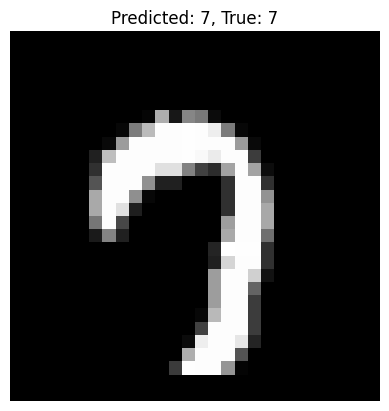

In [1]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

# 1. Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Preprocess input data
x_train = x_train.reshape((-1, 28, 28, 1)).astype('float32') / 255
x_test = x_test.reshape((-1, 28, 28, 1)).astype('float32') / 255

# 3. One-hot encode labels
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# 4. Build CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# 5. Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 6. Train model
model.fit(x_train, y_train_cat, epochs=5, batch_size=128, validation_split=0.1)

# 7. Evaluate on test data
loss, accuracy = model.evaluate(x_test, y_test_cat)
print(f"\nTest accuracy: {accuracy:.4f}")

# 8. Predict a single digit from the test set
index = np.random.randint(0, x_test.shape[0])
image = x_test[index]
true_label = y_test[index]

# Predict
prediction = model.predict(np.expand_dims(image, axis=0))
predicted_label = np.argmax(prediction)

# Show result
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Predicted: {predicted_label}, True: {true_label}")
plt.axis('off')
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import numpy as np

# 1. Load dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 2. Preprocess input data
x_train = x_train.reshape((-1, 28, 28, 1)).astype('float32') / 255
x_test = x_test.reshape((-1, 28, 28, 1)).astype('float32') / 255

# 3. One-hot encode labels
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# 4. Build CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# 5. Compile model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 6. Train model
model.fit(x_train, y_train_cat, epochs=5, batch_size=128, validation_split=0.1)

# 7. Predict and calculate accuracy manually
y_pred_probs = model.predict(x_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)
correct = np.sum(y_pred_labels == y_test)
accuracy = correct / len(y_test)

print(f"\nManual Test Accuracy: {accuracy:.4f}")


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - accuracy: 0.8766 - loss: 0.4684 - val_accuracy: 0.9770 - val_loss: 0.0876
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9767 - loss: 0.0796 - val_accuracy: 0.9837 - val_loss: 0.0593
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 57ms/step - accuracy: 0.9855 - loss: 0.0502 - val_accuracy: 0.9860 - val_loss: 0.0546
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 55ms/step - accuracy: 0.9899 - loss: 0.0340 - val_accuracy: 0.9883 - val_loss: 0.0503
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 54ms/step - accuracy: 0.9925 - loss: 0.0250 - val_accuracy: 0.9890 - val_loss: 0.0439
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

Manual Test Accuracy: 0.9873


In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
import numpy as np

# 1. Load Fashion MNIST dataset (images of clothes)
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# 2. Preprocess input data
x_train = x_train.reshape((-1, 28, 28, 1)).astype('float32') / 255
x_test = x_test.reshape((-1, 28, 28, 1)).astype('float32') / 255

# 3. One-hot encode the labels (e.g., 3 → [0, 0, 0, 1, 0, ...])
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# 4. Build CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')  # 10 classes for fashion items
])

# 5. Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 6. Train the model
model.fit(x_train, y_train_cat, epochs=5, batch_size=128, validation_split=0.1)

# 7. Predict on test data and calculate accuracy manually
y_pred_probs = model.predict(x_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)

correct = np.sum(y_pred_labels == y_test)
accuracy = correct / len(y_test)

print(f"\nManual Test Accuracy: {accuracy:.4f}")


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.7695 - loss: 0.6616 - val_accuracy: 0.8775 - val_loss: 0.3408
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 57ms/step - accuracy: 0.8835 - loss: 0.3271 - val_accuracy: 0.8970 - val_loss: 0.2954
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 58ms/step - accuracy: 0.9056 - loss: 0.2675 - val_accuracy: 0.9048 - val_loss: 0.2722
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 57ms/step - accuracy: 0.9158 - loss: 0.2353 - val_accuracy: 0.9082 - val_loss: 0.2510
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 40s 56ms/step - accuracy: 0.9249 - loss: 0.2089 - val_accuracy: 0.9085 - val_loss: 0.2464
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

Manual Test Accuracy: 0.9085
